### Фокин Н. А. 5130901/30201

# Упражнения по главе 3.

### Упражнение 3.1.

В ходе выполнения данного упражнения были построены окна Хэмминга и Бартлетта для синусоидального сигнала.

In [49]:
from thinkdsp import SinSignal

signal = SinSignal(freq=440)
wave = signal.make_wave(signal.period * 30.25)
spectrum = wave.make_spectrum()

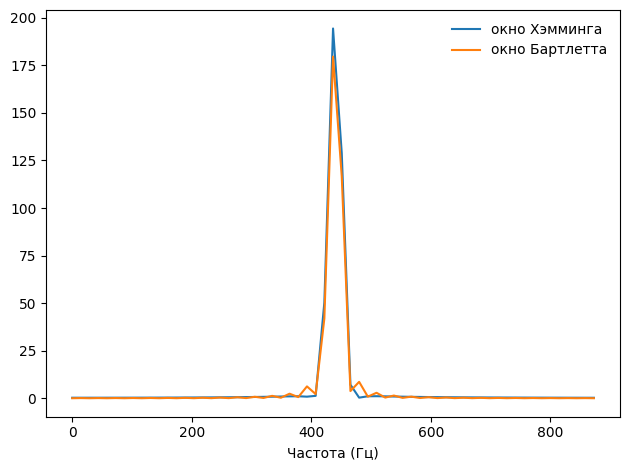

In [50]:
import numpy as np
from thinkdsp import decorate

wave = signal.make_wave(signal.period * 30.25)
wave.ys *= np.hamming(len(wave.ys))
spectrum = wave.make_spectrum()
spectrum.plot(high=880, label='окно Хэмминга')

wave = signal.make_wave(signal.period * 30.25)
wave.ys *= np.bartlett(len(wave.ys))
spectrum = wave.make_spectrum()
spectrum.plot(high=880, label='окно Бартлетта')
decorate(xlabel='Частота (Гц)')

Таким образом, окна Хэмминга и Бартлетта обеспечивают эффективное подавление спектральной утечки. При этом окно Бартлетта демонстрирует незначительный остаточный звон в частотной области, что указывает на меньшую гладкость спада боковых лепестков. Окно Хэмминга, в свою очередь, характеризуется минимальными потерями энергии сигнала.

### Упражнение 3.2.

В ходе выполнения данного упражнения был создан класс SawtoothChirp для генерации пилообразного сигнала с линейно увеличивающейся частотой.


In [51]:
from thinkdsp import Chirp
from thinkdsp import normalize, unbias
import numpy as np

class SawtoothChirp(Chirp):
    def evaluate(self, ts):
        freqs = np.linspace(self.start, self.end, len(ts))
        dts = np.diff(ts, prepend=0)
        dphis = 2*np.pi * freqs * dts
        phases = np.cumsum(dphis)
        cycles = phases / (2*np.pi)
        frac, _ = np.modf(cycles)
        ys =  normalize(unbias(frac), self.amp)
        return ys

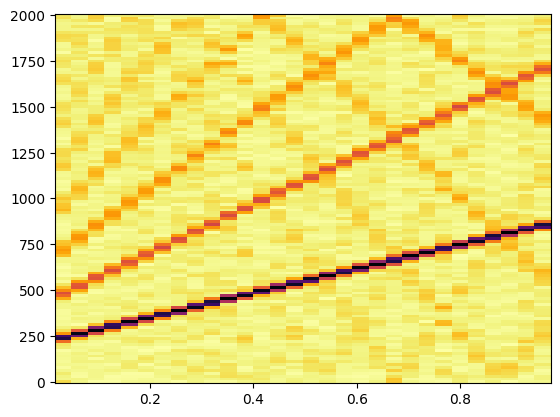

In [52]:
signal = SawtoothChirp(start=220, end=880)
wave = signal.make_wave(duration=1, framerate=4000)
spectrogram = wave.make_spectrogram(256)
spectrogram.plot()


In [53]:
wave.make_audio()

Спектрограмма наглядно демонстрирует эффект биений, обусловленный дискретными гармониками пилообразной формы, что также подтверждается при прослушивании.

### Упражнение 3.3.

С помощью созданного в предыдущем упражнении класса пилообразного сигнала был построен чирп, меняющийся от 2500 до 3000 Гц.

In [54]:
signal = SawtoothChirp(2500, 3000)
wave = signal.make_wave(duration=1, framerate=20000)

Также было изображено, каким ожидается увидеть спектр этого сигнала

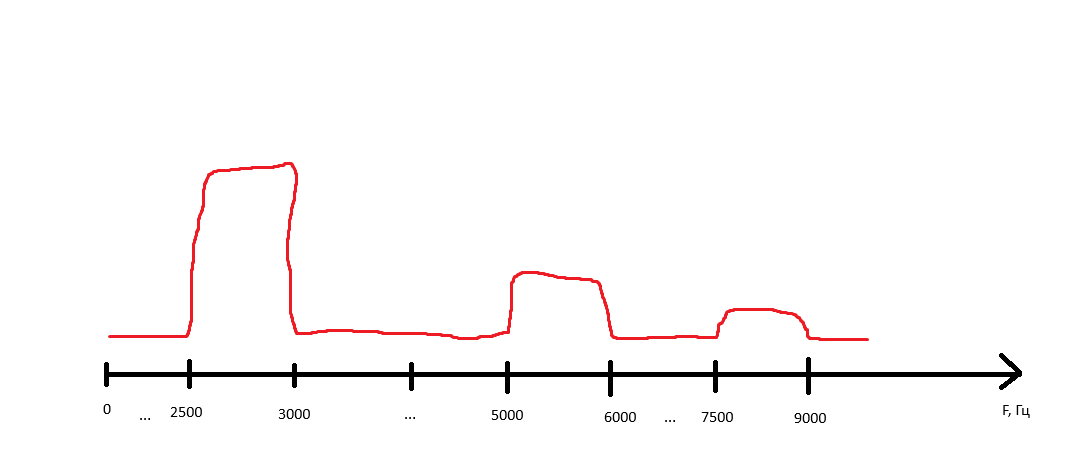

In [55]:
from IPython.display import Image
Image(filename='guess.png')

После чего был получен его фактический спектр, а также спектрограмма

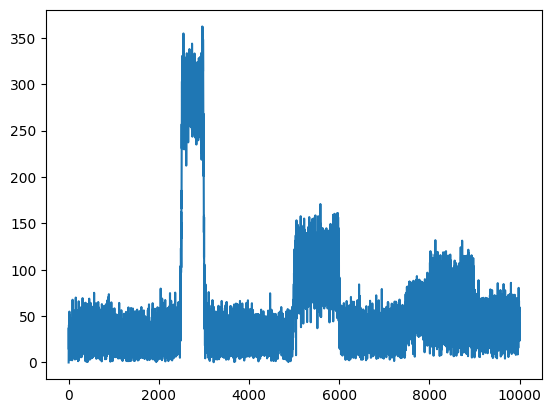

In [56]:
s = wave.make_spectrum()
s.plot()

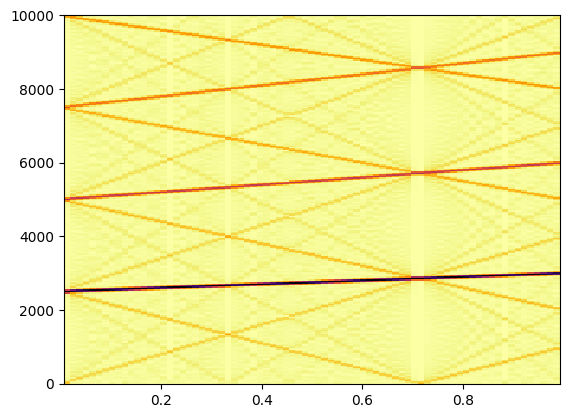

In [57]:
sp = wave.make_spectrogram(512)
sp.plot()

Таким образом, предположение оказалось верным: отчетливо наблюдаются три характерные структуры, соответствующие основной частоте (2500-3000 Гц), первой гармонике (5000-6000 Гц) и второй гармонике (7500-9000 Гц), причём интенсивность каждой последующей гармоники закономерно убывает.

### Упражнение 3.4.

В ходе данного упражнения был выделен сегмент с глиссандо из песни «Rhapsody in Blue» Джорджа Гершвина.


In [58]:
from thinkdsp import read_wave

wave = read_wave('rhapblue11924.wav').segment(start=6, duration=3)
wave.make_audio()

Также была построена его спектрограмма

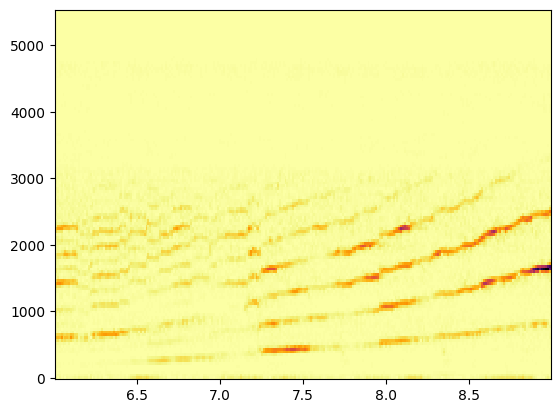

In [59]:
wave.make_spectrogram(256).plot()

### Упражнение 3.5.

В ходе выполнения данного задания был создан класс для имитации глиссандо

In [70]:
class TromboneGliss(Chirp):
    def evaluate(self, ts):
        fs = 1 / np.linspace(1/self.start, 1/self.end, len(ts))
        dts = np.diff(ts, prepend=0)
        dphis = 2*np.pi*fs*dts
        ps = np.cumsum(dphis)
        ys = self.amp*np.cos(ps)
        return ys


С помощью данного класса был получен сигнал, имитирующий глиссандо на тромбоне от ноты C3 до F3 и обратно в C3

In [71]:
signal_up = TromboneGliss(262, 349)
signal_down = TromboneGliss(349, 262)
wave = signal_up.make_wave(duration=1) | signal_down.make_wave(duration=1)
wave.make_audio()

Была получена его спектрограмма

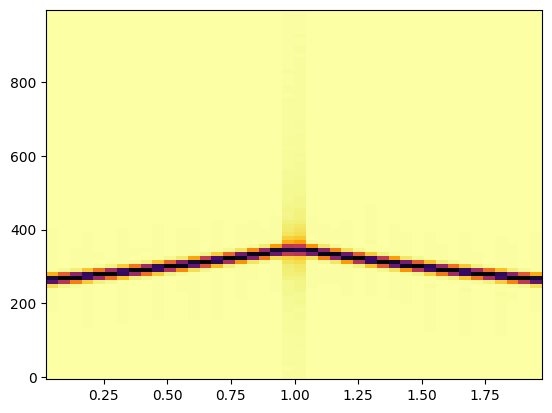

In [69]:
sp = wave.make_spectrogram(1024)
sp.plot(high=1000)

### Упражнение 3.6.

В ходе выполнения данного задания были записаны звуки гласных русского алфавита, а также были проанализированы их спектрограммы.

In [92]:
import matplotlib.pyplot as plt
sps = {}

for i in 'а е ё и о у ы э ю я'.split():
    sps[i] = read_wave(f'vowels/{i}.wav').make_spectrogram(1024)

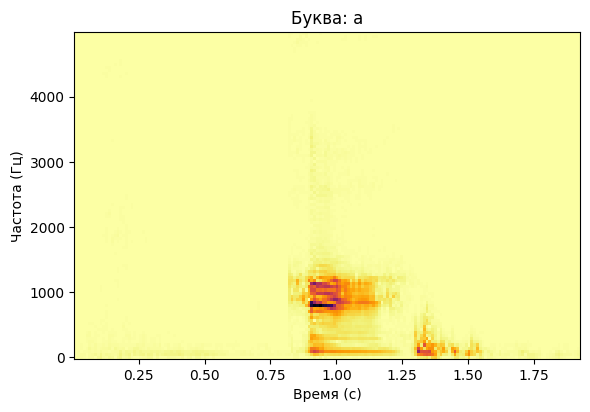

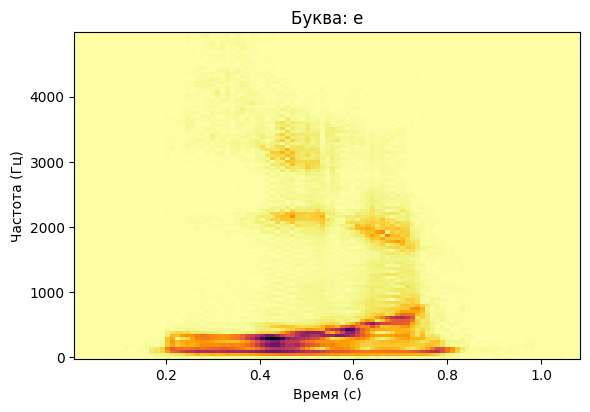

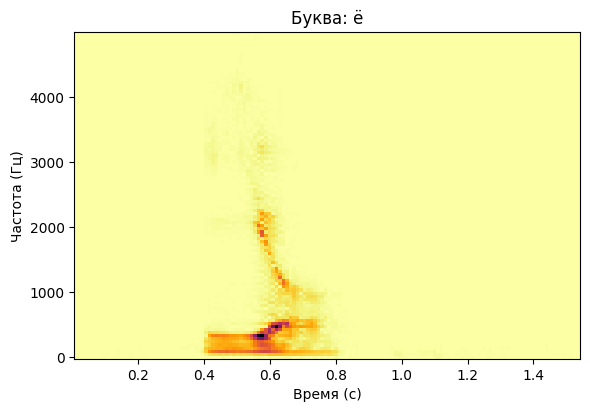

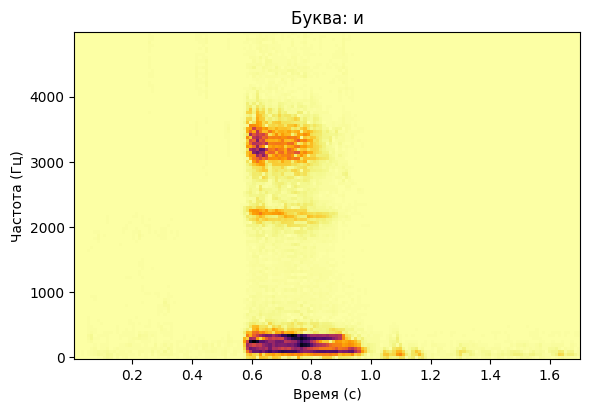

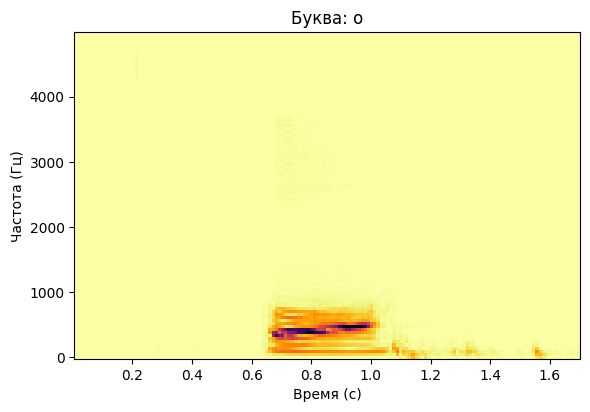

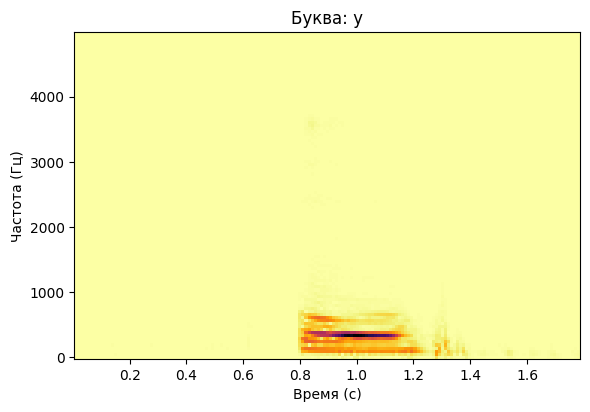

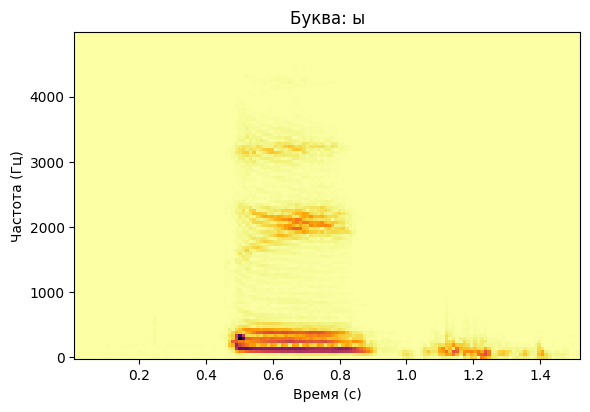

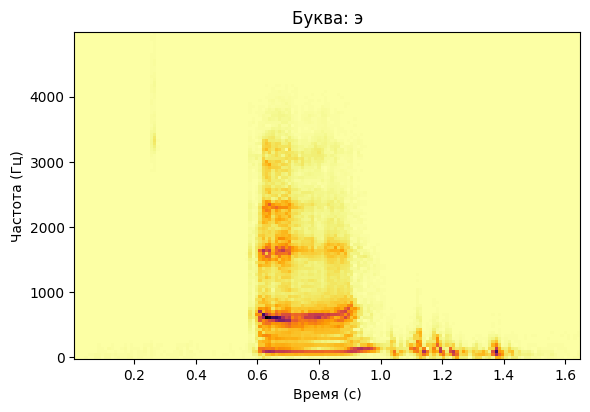

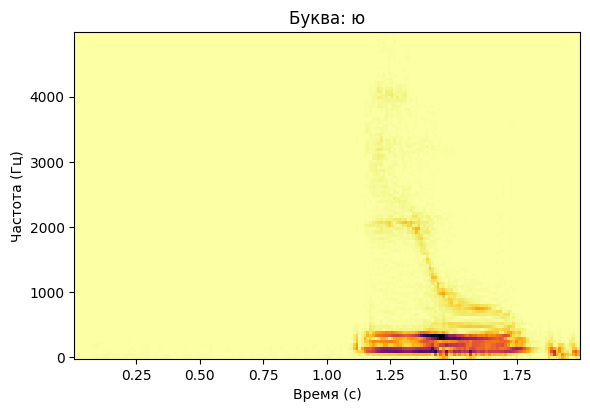

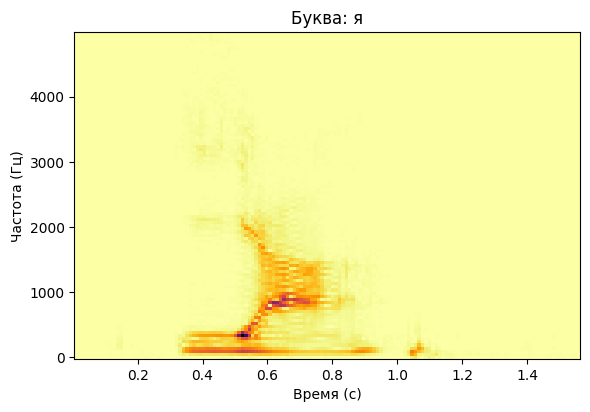

In [99]:
for letter, sp in sps.items():
    plt.figure(figsize=(6, 4))
    sp.plot(high=5000)
    decorate(xlabel='Время (с)', ylabel='Частота (Гц)')
    plt.title(f'Буква: {letter}')
    plt.show()

Если не учитывать влияние шумов на качество созданных аудиозаписей, то по полученным спектрограммам можно сказать следующее:

1. Буквы "О" и "У" имеют крайне схожие спектрограммы с основной частотой окло 450 Гц, и, следовательно, скорее всего по ним различить буквы не получится
2. 'А' имеет основную частоту около 1000 Гц, и ее спектрограмма похожа на спектрограмму буквы 'Я', частота которой чуть ниже, но тем не менее отличить их друг от друга вероятно будет трудоемкой задачей
3. Основные частоты букв Е, Ё, Ю лежат в пределах 500 Гц, при детальном анализе, возможно, получиться выявить отличающие их друг от друга закономерности
4. Спектрограммы букв Э и Ы обладают схожими вытянутыми полосами частот до ~3500 Гц.